<a href="https://colab.research.google.com/github/pvsk0226/IMDb-Movie-Analysis/blob/main/Nutriclass/Nutri_class_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_food_dataset_imbalanced.csv to synthetic_food_dataset_imbalanced.csv


In [2]:
import pandas as pd
import io
df = pd.read_csv('synthetic_food_dataset_imbalanced.csv')
df['Food_Name'].nunique()
df['Food_Name'].value_counts().head(20)

,count
Food_Name,
Pizza,6000
Burger,5000
Donut,4500
Pasta,4000
Sushi,3500
Ice Cream,3000
Steak,2000
Apple,1500
Banana,1200


In [3]:
print(df.dtypes)

Calories              float64
Protein               float64
Fat                   float64
Carbs                 float64
Sugar                 float64
Fiber                 float64
Sodium                float64
Cholesterol           float64
Glycemic_Index        float64
Water_Content         float64
Serving_Size          float64
Meal_Type              object
Preparation_Method     object
Is_Vegan                 bool
Is_Gluten_Free           bool
Food_Name              object
dtype: object


In [4]:
# Show 3 random rows from the dataset
print(df.sample(3))

# Show sample entries per class
for food in df['Food_Name'].unique():
    print(f"\nSample rows for {food}:")
    print(df[df['Food_Name'] == food].head(2))


         Calories    Protein        Fat      Carbs     Sugar     Fiber  \
26608  300.064217   9.151146   9.099212  41.659077  2.447884  1.600028   
30629  173.234477  10.092660   6.624141  30.389952  3.387043  1.937528   
29176  256.987641   9.790260  11.012862  29.980152  4.638744  3.460615   

           Sodium  Cholesterol  Glycemic_Index  Water_Content  Serving_Size  \
26608   25.204379    11.799155       75.072870      31.551227    166.177741   
30629  347.215666    25.912213       64.622856      51.037478    140.672759   
29176  596.423680    18.930229       75.191035      38.680200    197.083308   

       Meal_Type Preparation_Method  Is_Vegan  Is_Gluten_Free Food_Name  
26608  breakfast            grilled     False           False     Pasta  
30629  breakfast              fried     False            True     Sushi  
29176  breakfast            grilled     False           False     Pizza  

Sample rows for Pizza:
      Calories    Protein        Fat      Carbs     Sugar     Fibe

## Calories distribution by Food Type

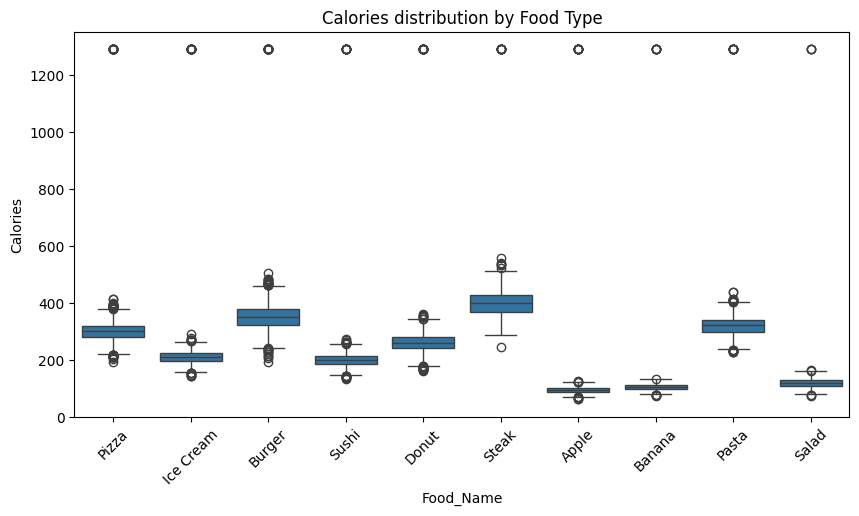

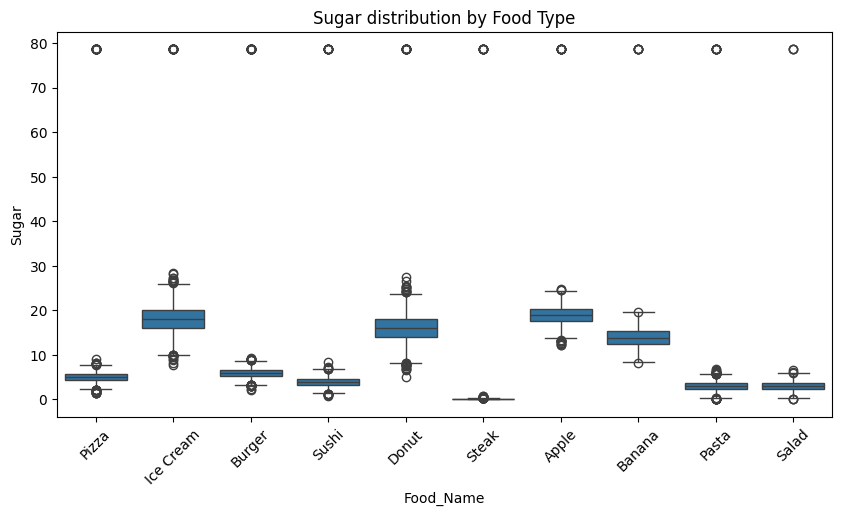

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare Calories across classes
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Food_Name", y="Calories")
plt.xticks(rotation=45)
plt.title("Calories distribution by Food Type")
plt.show()

# Compare Sugar across classes
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Food_Name", y="Sugar")
plt.xticks(rotation=45)
plt.title("Sugar distribution by Food Type")
plt.show()

Based on the box plots, here's what we can understand about the calorie and sugar distribution across different food types:

**Calories Distribution:**

*   **Pizza and Burger** generally have the highest calorie content, with a wide range of values.
*   **Steak** also shows a high calorie range, similar to Pizza and Burger.
*   **Ice Cream and Donut** have moderate calorie ranges.
*   **Sushi, Pasta, Apple, and Banana** tend to have lower calorie content compared to the other food types.
*   **Salad** has the lowest calorie content, as expected.

**Sugar Distribution:**

*   **Donut and Ice Cream** have the highest sugar content, with Donut showing a particularly wide distribution.
*   **Apple and Banana** also have relatively high sugar content, which is expected for fruits.
*   **Pizza, Burger, Pasta, and Sushi** have lower sugar content compared to desserts and fruits.
*   **Steak and Salad** have very low sugar content.

These plots highlight the significant differences in calorie and sugar profiles across the various food types in the dataset.

## Data Cleaning

In [6]:
# Check missing values
print(df.isnull().sum())

# Check basic stats
print(df.describe())

# Check for negative values (Calories, Protein, Fat etc. must be ≥ 0)
numeric_cols = ['Calories','Protein','Fat','Carbs','Sugar','Fiber',
                'Sodium','Cholesterol','Glycemic_Index','Water_Content','Serving_Size']

for col in numeric_cols:
    print(col, (df[col] < 0).sum(), "negative values")


Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64
           Calories       Protein           Fat         Carbs         Sugar  \
count  31325.000000  31325.000000  31325.000000  31325.000000  31325.000000   
mean     273.378441      9.523802     12.476848     28.943200      8.543813   
std      111.457160      8.024212      8.425834     12.668795      7.989075   
min       60.786204      0.000000      0.000000      0.000000      0.000000   
25%      210.301731      3.858307      8.245636     25.098800      3.739656   
50%      281.774249      9.091637     11.574161     29.681430      5.500479   
75%      329.82194

Checking whether replacing the missing value affect the future model

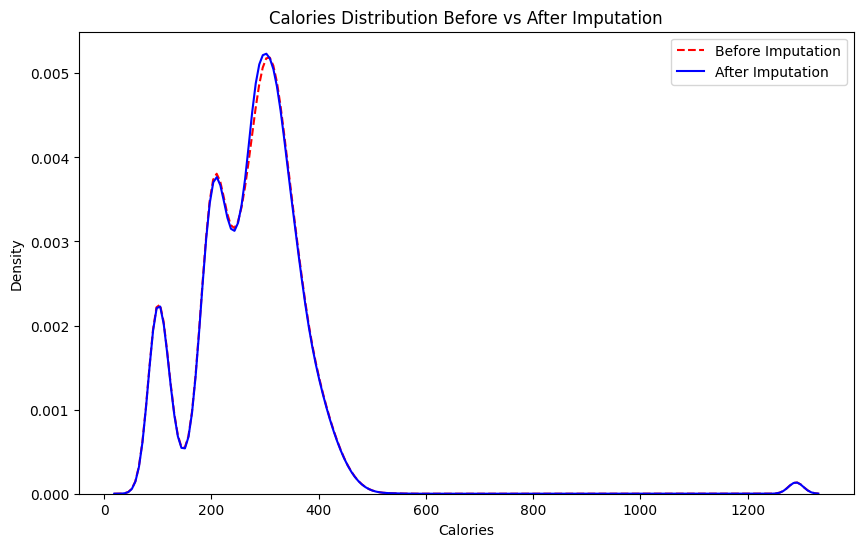

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Compare "Calories" before & after filling

# 1️⃣ Make a copy of the original column (with NaN values still there)
df_before = df['Calories'].copy()

# 2️⃣ Fill missing values using median (like we discussed)
df['Calories'] = df['Calories'].fillna(df['Calories'].median())

# 3️⃣ Compare distributions
plt.figure(figsize=(10,6))

sns.kdeplot(df_before, label="Before Imputation", color="red", linestyle="--")
sns.kdeplot(df['Calories'], label="After Imputation", color="blue")

plt.title("Calories Distribution Before vs After Imputation")
plt.xlabel("Calories")
plt.ylabel("Density")
plt.legend()
plt.show()


### Filing the missing values

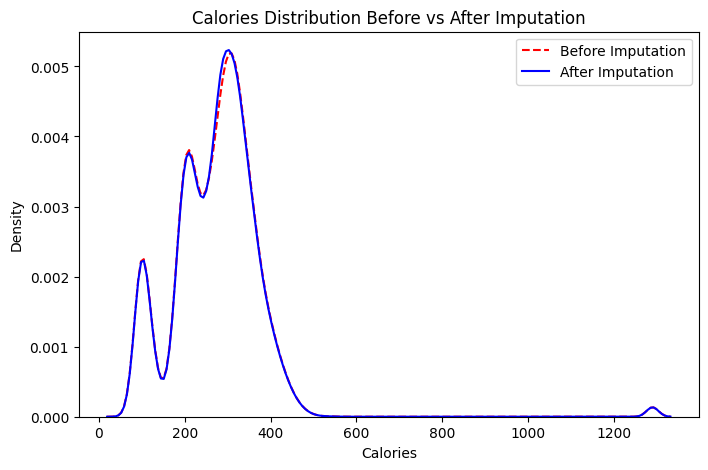

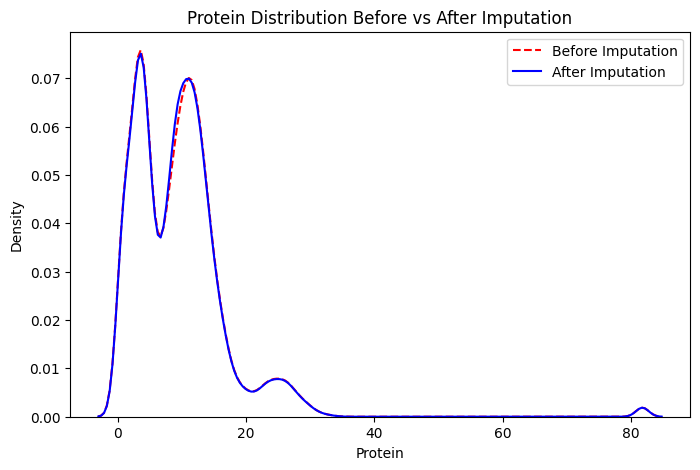

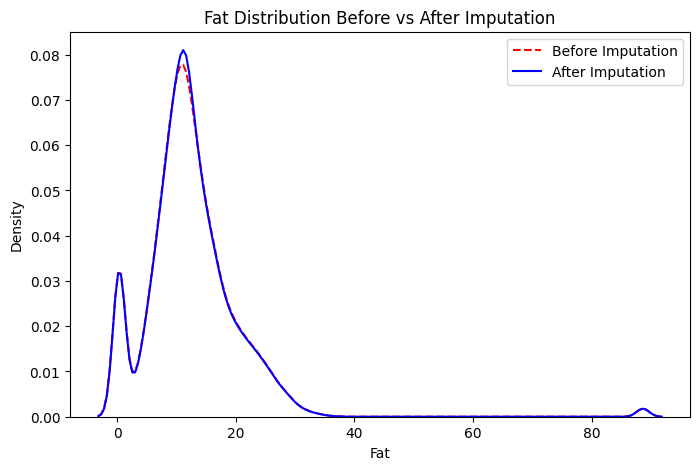

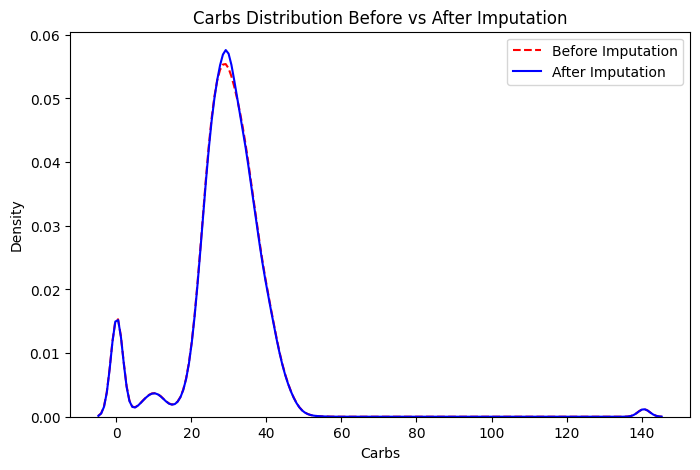

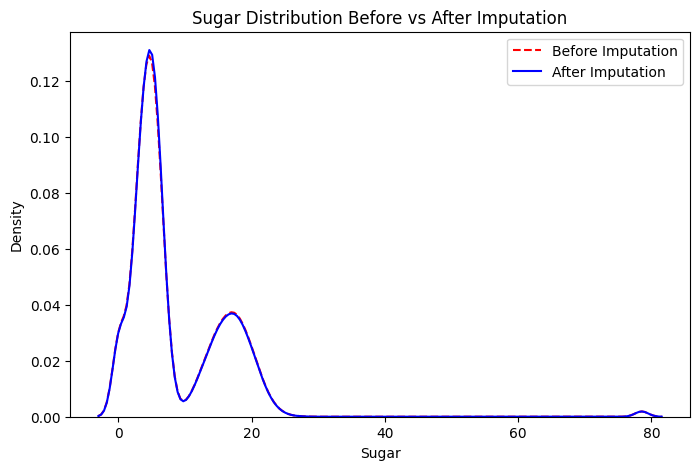

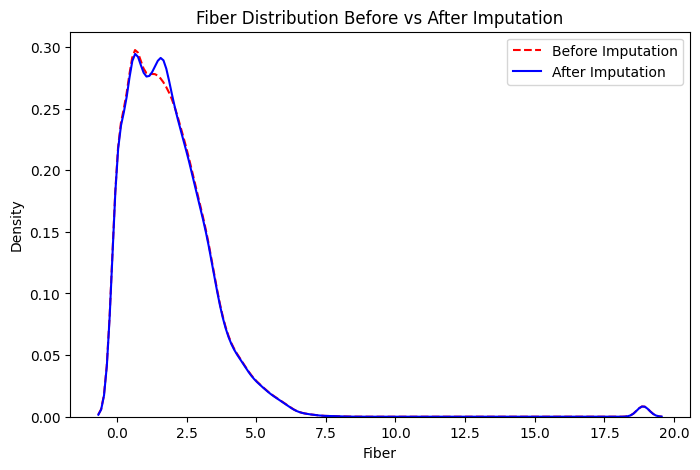

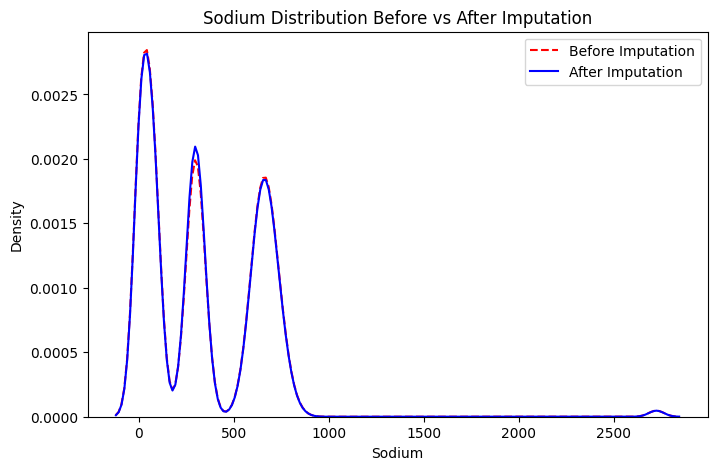

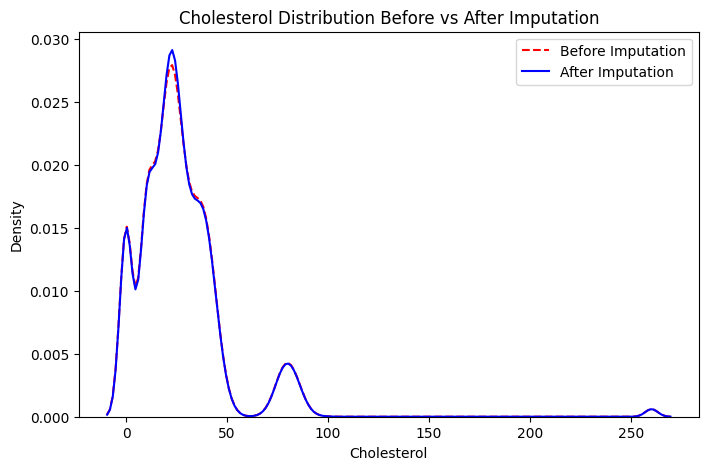

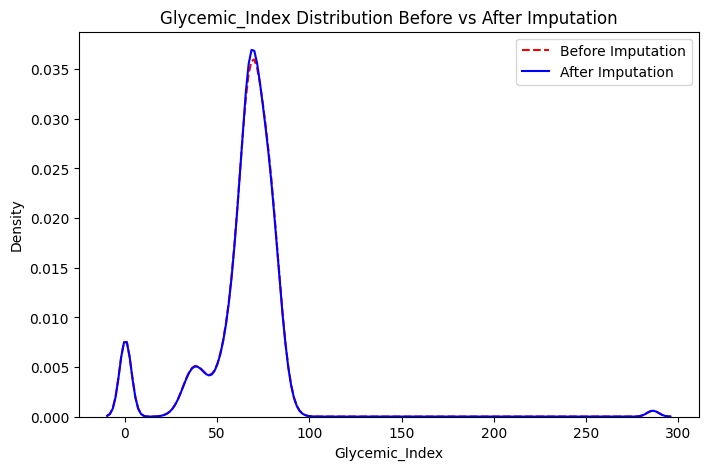

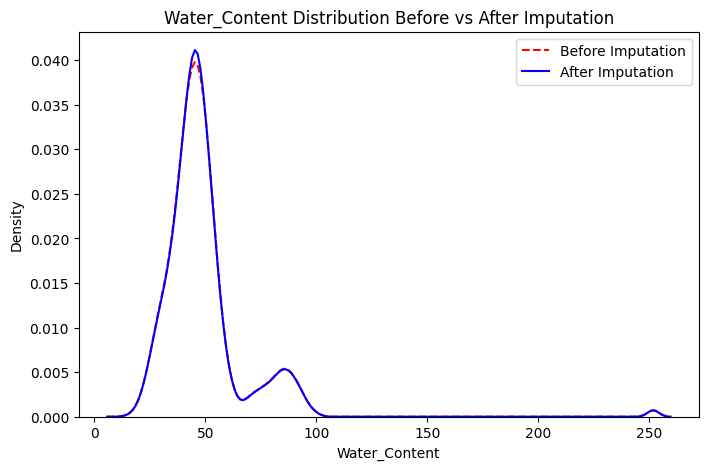

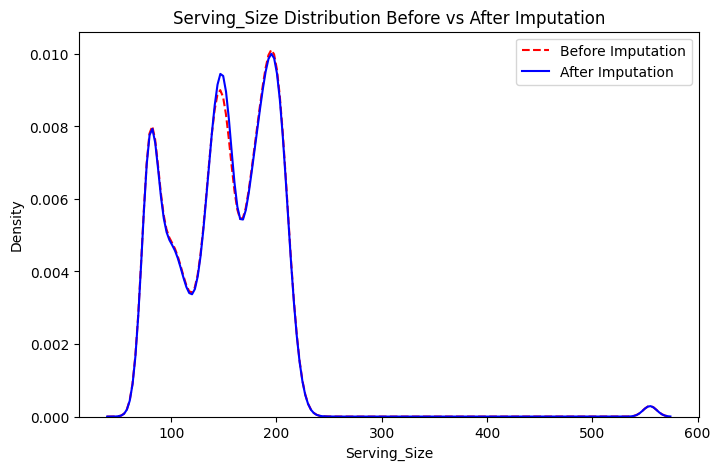

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copy original dataset before filling
df_original = df.copy()

# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Loop through each numeric column and plot
for col in numeric_cols:
    plt.figure(figsize=(8,5))

    sns.kdeplot(df_original[col].dropna(), label="Before Imputation", color="red", linestyle="--")
    sns.kdeplot(df[col], label="After Imputation", color="blue")

    plt.title(f"{col} Distribution Before vs After Imputation")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [8]:
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)      # fill missing

In [9]:
# Check missing values
print(df.isnull().sum())

# Check basic stats
print(df.describe())

# Check for negative values (Calories, Protein, Fat etc. must be ≥ 0)
numeric_cols = ['Calories','Protein','Fat','Carbs','Sugar','Fiber',
                'Sodium','Cholesterol','Glycemic_Index','Water_Content','Serving_Size']

for col in numeric_cols:
    print(col, (df[col] < 0).sum(), "negative values")

Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64
           Calories       Protein           Fat         Carbs         Sugar  \
count  31700.000000  31700.000000  31700.000000  31700.000000  31700.000000   
mean     273.477761      9.518690     12.466169     28.951933      8.507812   
std      110.799647      7.976744      8.376415     12.593889      7.948493   
min       60.786204      0.000000      0.000000      0.000000      0.000000   
25%      210.965764      3.890890      8.287972     25.173127      3.766235   
50%      281.774249      9.091637     11.574161     29.681430      5.500479   
75%      329.279969     12.641817     15.749813   

In [18]:
# Visualize sample entries per class to understand inter-class variation
for food in df['Food_Name'].unique():
    print(f"\nSample rows for {food}:")
    # Show a few sample rows for each food type
    print(df[df['Food_Name'] == food].sample(min(3, len(df[df['Food_Name'] == food]))))


Sample rows for Pizza:
         Calories    Protein        Fat      Carbs     Sugar     Fiber  \
2238   351.997766  10.667644  14.038416  35.506155  3.905042  4.046124   
14577  295.462933  15.079065   4.440917  28.855558  4.142901  1.986860   
9187   311.583465  11.186788  12.777442  36.116777  5.830372  3.387689   

           Sodium  Cholesterol  Glycemic_Index  Water_Content  Serving_Size  \
2238   769.108883    30.319819       84.040124      37.839535    204.936873   
14577  646.429494    32.174489       85.218241      39.625709    203.028083   
9187   523.366718    15.275526       76.900887      36.033792    195.598431   

       Meal_Type Preparation_Method  Is_Vegan  Is_Gluten_Free Food_Name  
2238   breakfast              baked     False           False     Pizza  
14577      lunch                raw     False           False     Pizza  
9187       lunch                raw     False           False     Pizza  

Sample rows for Ice Cream:
         Calories   Protein        Fat


## Analyzing the dataset for imbalance and noise by visualizing the distributions of categorical and numerical features.

In [19]:
# Check dataset size
print(f"Dataset size: {df.shape[0]} rows, {df.shape[1]} columns")

# Check imbalance in 'Food_Name'
print("\nDistribution of Food_Name:")
print(df['Food_Name'].value_counts())

# Check for noise in categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Dataset size: 31700 rows, 16 columns

Distribution of Food_Name:
Food_Name
Pizza        6000
Burger       5000
Donut        4500
Pasta        4000
Sushi        3500
Ice Cream    3000
Steak        2000
Apple        1500
Banana       1200
Salad        1000
Name: count, dtype: int64

Unique values in categorical columns:
Meal_Type: ['dinner' 'snack' 'lunch' 'breakfast']
Preparation_Method: ['fried' 'raw' 'baked' 'grilled']
Food_Name: ['Pizza' 'Ice Cream' 'Burger' 'Sushi' 'Donut' 'Steak' 'Apple' 'Banana'
 'Pasta' 'Salad']


Based on the output of the last cell, we can understand the following:

Dataset Size: The dataset contains 31,700 rows and 16 columns. This gives us an idea of the total number of data points and features we are working with.
Imbalance in 'Food_Name': The value_counts() output for the 'Food_Name' column shows that the dataset is imbalanced. Some food types (like Pizza, Burger, Donut, Pasta, and Sushi) have a significantly higher number of entries than others (like Steak, Apple, Banana, and Salad). This imbalance is important to consider when building a classification model, as it can lead to biased results where the model performs well on the majority classes but poorly on the minority classes. Techniques like resampling (oversampling or undersampling) or using evaluation metrics appropriate for imbalanced datasets will be necessary later on.
Noise in Categorical Columns: The unique values for the 'Meal_Type' and 'Preparation_Method' columns show a limited and expected set of categories. The 'Food_Name' column also shows the 10 distinct food types, which aligns with our understanding of the dataset. There don't appear to be any unexpected or noisy values in these categorical columns, which is good for data quality.
In summary, the dataset is of a reasonable size, but it has a notable class imbalance in the target variable ('Food_Name'). The categorical features seem clean and do not show obvious signs of noise. This information will guide the subsequent steps in preparing the data for modeling, particularly in addressing the class imbalance.

## Detecting and removing cap outliers

In [20]:
# Detecting and removing or cap outliers.

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate IQR for each numeric column
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers (optional, for inspection)
outliers_indices = {}
for col in numeric_cols:
    outliers_indices[col] = df[(df[col] < lower_bound[col]) | (df[col] > upper_bound[col])].index

# Option 1: Capping outliers
df_capped = df.copy()
for col in numeric_cols:
    df_capped[col] = df_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])

# Display descriptive statistics before and after capping for comparison
print("Descriptive statistics BEFORE capping outliers:")
print(df[numeric_cols].describe())

print("\nDescriptive statistics AFTER capping outliers:")
print(df_capped[numeric_cols].describe())

# You can now use df_capped for further analysis or modeling
df = df_capped

Descriptive statistics BEFORE capping outliers:
           Calories       Protein           Fat         Carbs         Sugar  \
count  31700.000000  31700.000000  31700.000000  31700.000000  31700.000000   
mean     273.477761      9.518690     12.466169     28.951933      8.507812   
std      110.799647      7.976744      8.376415     12.593889      7.948493   
min       60.786204      0.000000      0.000000      0.000000      0.000000   
25%      210.965764      3.890890      8.287972     25.173127      3.766235   
50%      281.774249      9.091637     11.574161     29.681430      5.500479   
75%      329.279969     12.641817     15.749813     34.565347     14.318014   
max     1289.956763     81.761772     88.619611    140.585537     78.548162   

              Fiber        Sodium   Cholesterol  Glycemic_Index  \
count  31700.000000  31700.000000  31700.000000    31700.000000   
mean       1.900999    334.880564     26.822825       64.263462   
std        1.769203    317.207066     2

## Remove duplicate entries.

In [21]:
# Check for duplicate entries
print(f"Number of rows before removing duplicates: {df.shape[0]}")
df_cleaned = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {df_cleaned.shape[0]}")

# Update the main dataframe
df = df_cleaned

Number of rows before removing duplicates: 31700
Number of rows after removing duplicates: 31387


In [22]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_df = df[numeric_cols]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numeric data
numeric_scaled = scaler.fit_transform(numeric_df)

# Convert the scaled data back to a DataFrame
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=numeric_cols)

# Display descriptive statistics of the scaled data
print("Descriptive statistics of scaled numerical features:")
display(numeric_scaled_df.describe())

# You can now use numeric_scaled_df for further analysis or modeling

Descriptive statistics of scaled numerical features:


,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04,3.138700e+04
mean,4.043169e-16,1.283582e-16,7.244199e-18,7.189868e-16,1.408091e-16,-4.754006e-18,1.494116e-16,-2.186843e-16,-1.110174e-15,-1.258680e-16,-9.621202e-17
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00
min,-2.388000e+00,-1.484975e+00,-1.869024e+00,-2.204092e+00,-1.279620e+00,-1.375471e+00,-1.171031e+00,-1.469407e+00,-2.056804e+00,-2.240370e+00,-2.044912e+00
25%,-6.734555e-01,-8.594161e-01,-5.937129e-01,-4.976315e-01,-6.993834e-01,-8.154352e-01,-9.449060e-01,-7.243611e-01,-4.147544e-01,-6.333125e-01,-8.931528e-01
50%,1.440172e-01,-1.245432e-02,-8.031614e-02,5.757042e-02,-4.271878e-01,-1.343284e-01,-1.232482e-01,-1.057875e-01,1.952268e-01,-9.560468e-02,5.574193e-02
75%,6.893166e-01,5.636058e-01,5.662065e-01,6.526491e-01,9.415954e-01,6.261968e-01,1.085519e+00,5.793405e-01,6.975061e-01,4.500913e-01,8.930278e-01
max,2.721739e+00,2.688556e+00,2.294768e+00,2.364914e+00,3.392184e+00,2.775833e+00,4.126276e+00,2.517352e+00,2.348780e+00,2.062686e+00,3.549660e+00


## Normalize or standardize numerical features.

# Task
Apply feature selection to reduce the dimensionality of the dataset.

## Apply feature selection

### Subtask:
Use a feature selection method to identify the most relevant features.


**Reasoning**:
The subtask is to select the most relevant features using SelectKBest and f_classif. This requires importing the necessary modules, instantiating SelectKBest, fitting it to the data, and getting the mask of selected features. These steps can be combined into a single code block.



In [23]:
from sklearn.feature_selection import SelectKBest, f_classif

# Instantiate SelectKBest
k_best_features = SelectKBest(score_func=f_classif, k=5)

# Fit SelectKBest to the scaled numeric features and the target variable
k_best_features.fit(numeric_scaled_df, df['Food_Name'])

# Get the boolean mask of the selected features
selected_features_mask = k_best_features.get_support()

## Analyze feature selection results


Examining the selected features and their importance scores (if applicable).


**Reasoning**:
Create a list of selected feature names, get the scores, and display them sorted to understand feature importance.



In [24]:
# 1. Create a list of the names of the selected numeric columns
selected_numeric_features = [numeric_cols[i] for i, is_selected in enumerate(selected_features_mask) if is_selected]

# 2. Get the scores for each feature
feature_scores = k_best_features.scores_

# 3. Create a pandas Series to display feature names and scores, sorted
feature_scores_series = pd.Series(feature_scores, index=numeric_cols)
sorted_feature_scores = feature_scores_series.sort_values(ascending=False)

# 4. Print the sorted feature names and scores
print("Feature importance scores (sorted):")
print(sorted_feature_scores)

Feature importance scores (sorted):
Sodium            45233.960069
Serving_Size      37147.638486
Cholesterol       36545.124388
Sugar             28664.848347
Protein           24760.692525
Glycemic_Index    22254.052220
Calories          20505.812784
Water_Content     17824.645443
Fat               13893.172513
Carbs             10055.431889
Fiber              4925.397907
dtype: float64


## Transform data


Creating a new DataFrame with the selected features and combine them with categorical features.



Selecting the selected numeric columns and categorical columns from the original dataframe and combine them into a new dataframe. Then display the head and columns of the new dataframe to verify.



In [25]:
# Select the columns from the original DataFrame df that correspond to the selected_numeric_features.
df_selected_numeric = df[selected_numeric_features]

# Select the categorical columns from the original DataFrame df.
categorical_cols = df.select_dtypes(include='object').columns
df_categorical = df[categorical_cols]

# Concatenate df_selected_numeric and df_categorical along the columns axis.
df_transformed = pd.concat([df_selected_numeric, df_categorical], axis=1)

# Display the first few rows and the columns of df_transformed.
print("First few rows of the transformed DataFrame:")
display(df_transformed.head())

print("\nColumns of the transformed DataFrame:")
print(df_transformed.columns)

First few rows of the transformed DataFrame:


,Protein,Sugar,Sodium,Cholesterol,Serving_Size,Meal_Type,Preparation_Method,Food_Name
0,14.340084,4.828030,647.553389,24.990309,197.570043,dinner,fried,Pizza
1,4.080908,16.347814,68.572414,34.301652,103.833510,snack,raw,Ice Cream
2,14.326708,6.251137,663.171859,34.816834,198.989367,snack,raw,Burger
3,9.452445,2.984621,300.749543,28.510998,135.714202,lunch,fried,Sushi
4,6.099547,17.352958,296.314958,15.403173,73.019474,snack,baked,Donut



Columns of the transformed DataFrame:
Index(['Protein', 'Sugar', 'Sodium', 'Cholesterol', 'Serving_Size',
       'Meal_Type', 'Preparation_Method', 'Food_Name'],
      dtype='object')


## Summary:

### Data Analysis Key Findings

*   The `SelectKBest` method with the `f_classif` score function was used to select the top 5 features from the scaled numeric data.
*   The top 5 selected numeric features based on their F-statistic scores were 'Protein', 'Sugar', 'Sodium', 'Cholesterol', and 'Serving\_Size'. The features with the highest importance scores were 'Sodium', 'Serving\_Size', and 'Cholesterol'.
*   A new DataFrame, `df_transformed`, was created containing the selected numeric features ('Protein', 'Sugar', 'Sodium', 'Cholesterol', 'Serving\_Size') and all categorical features ('Meal\_Type', 'Preparation\_Method', and 'Food\_Name').

### Insights

*   The transformed DataFrame with reduced dimensionality can now be used for subsequent modeling tasks, potentially improving model performance and reducing computational cost.



## Encode class labels using label encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the 'Food_Name' column
df_transformed['Food_Name_Encoded'] = label_encoder.fit_transform(df_transformed['Food_Name'])

# Display the mapping of original labels to encoded labels
print("Mapping of Food_Name to encoded labels:")
for original_label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{original_label}: {encoded_label}")

# Display the first few rows with the new encoded column
print("\nFirst few rows of the transformed DataFrame with encoded labels:")
display(df_transformed.head())

Mapping of Food_Name to encoded labels:
Apple: 0
Banana: 1
Burger: 2
Donut: 3
Ice Cream: 4
Pasta: 5
Pizza: 6
Salad: 7
Steak: 8
Sushi: 9

First few rows of the transformed DataFrame with encoded labels:


,Protein,Sugar,Sodium,Cholesterol,Serving_Size,Meal_Type,Preparation_Method,Food_Name,Food_Name_Encoded
0,14.340084,4.828030,647.553389,24.990309,197.570043,dinner,fried,Pizza,6
1,4.080908,16.347814,68.572414,34.301652,103.833510,snack,raw,Ice Cream,4
2,14.326708,6.251137,663.171859,34.816834,198.989367,snack,raw,Burger,2
3,9.452445,2.984621,300.749543,28.510998,135.714202,lunch,fried,Sushi,9
4,6.099547,17.352958,296.314958,15.403173,73.019474,snack,baked,Donut,3


# Encode class labels using label encoding


Train and compare multiple classifiers:

● Logistic Regression

● Decision Tree

● Random Forest

● K-Nearest Neighbors

● Support Vector Machine

● XGBoost

● Gradient Boosting Classifier

## Split the data


Split the dataset into training and testing sets.



Split the data into training and testing sets and print their shapes.



In [27]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df_transformed.drop(['Food_Name', 'Food_Name_Encoded'], axis=1)
y = df_transformed['Food_Name_Encoded']

# Convert boolean columns to int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Handle categorical features for X by one-hot encoding
X = pd.get_dummies(X, columns=['Meal_Type', 'Preparation_Method'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (25109, 13)
Shape of X_test: (6278, 13)
Shape of y_train: (25109,)
Shape of y_test: (6278,)


## Handle class imbalance


Addressing the class imbalance in the training set using appropriate techniques (e.g., oversampling or undersampling).



Applying SMOTE to the training data to address class imbalance and print the value counts before and after applying SMOTE to show the effect.



In [28]:
from imblearn.over_sampling import SMOTE

# Print the value counts of the original y_train
print("Original y_train value counts:")
print(y_train.value_counts())

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the value counts of the resampled y_train
print("\nResampled y_train value counts:")
print(y_train_resampled.value_counts())

Original y_train value counts:
Food_Name_Encoded
6    4733
2    3950
3    3573
5    3180
9    2770
4    2374
8    1594
0    1187
1     954
7     794
Name: count, dtype: int64

Resampled y_train value counts:
Food_Name_Encoded
3    4733
6    4733
9    4733
4    4733
1    4733
5    4733
8    4733
2    4733
0    4733
7    4733
Name: count, dtype: int64


## Training and evaluating models


Train each of the specified classifiers on the balanced training data and evaluate their performance on the testing set using relevant metrics (e.g., accuracy, precision, recall, F1-score).



Importing the necessary classifier models and evaluation metrics, create a dictionary to store results, and then iterate through each classifier to train and evaluate it on the resampled training data and testing data respectively.



In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store performance results
model_performance = {}

# List of classifiers to train and evaluate
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42)
}

# Iterate through each classifier
for name, clf in classifiers.items():
    print(f"Training {name}...")

    # Train the model
    clf.fit(X_train_resampled, y_train_resampled)

    # Make predictions
    y_pred = clf.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store the metrics
    model_performance[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }
    print(f"{name} training and evaluation complete.\n")

# Display the performance metrics
performance_df = pd.DataFrame(model_performance).T
print("Model Performance on Testing Set:")
display(performance_df)

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression training and evaluation complete.

Training Decision Tree...
Decision Tree training and evaluation complete.

Training Random Forest...
Random Forest training and evaluation complete.

Training K-Nearest Neighbors...
K-Nearest Neighbors training and evaluation complete.

Training Support Vector Machine...
Support Vector Machine training and evaluation complete.

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:47:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training and evaluation complete.

Training Gradient Boosting Classifier...
Gradient Boosting Classifier training and evaluation complete.

Model Performance on Testing Set:


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.969098,0.969320,0.969098,0.969101
Decision Tree,0.979611,0.979756,0.979611,0.979647
Random Forest,0.986301,0.986305,0.986301,0.986288
K-Nearest Neighbors,0.982797,0.982941,0.982797,0.982838
Support Vector Machine,0.980886,0.981052,0.980886,0.980932
XGBoost,0.986461,0.986476,0.986461,0.986456
Gradient Boosting Classifier,0.986301,0.986347,0.986301,0.986301


## Compare model performance

### Subtask:
Compare the performance metrics of all trained models to identify the best-performing classifier.


**Reasoning**:
Examine the performance_df DataFrame to identify the best-performing classifier based on the evaluation metrics, paying attention to the F1-score.



In [30]:
print("Model Performance on Testing Set:")
display(performance_df)

# Identify the best model based on F1-score
best_model_f1 = performance_df['F1-score'].idxmax()
print(f"\nBest model based on F1-score: {best_model_f1}")

# Identify the best model based on Accuracy
best_model_accuracy = performance_df['Accuracy'].idxmax()
print(f"Best model based on Accuracy: {best_model_accuracy}")

# Identify the best model based on Precision
best_model_precision = performance_df['Precision'].idxmax()
print(f"Best model based on Precision: {best_model_precision}")

# Identify the best model based on Recall
best_model_recall = performance_df['Recall'].idxmax()
print(f"Best model based on Recall: {best_model_recall}")

Model Performance on Testing Set:


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.969098,0.969320,0.969098,0.969101
Decision Tree,0.979611,0.979756,0.979611,0.979647
Random Forest,0.986301,0.986305,0.986301,0.986288
K-Nearest Neighbors,0.982797,0.982941,0.982797,0.982838
Support Vector Machine,0.980886,0.981052,0.980886,0.980932
XGBoost,0.986461,0.986476,0.986461,0.986456
Gradient Boosting Classifier,0.986301,0.986347,0.986301,0.986301



Best model based on F1-score: XGBoost
Best model based on Accuracy: XGBoost
Best model based on Precision: XGBoost
Best model based on Recall: XGBoost


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully split into training and testing sets with a test size of 20%.
*   SMOTE was effectively used to balance the classes in the training dataset, resulting in an equal count for all classes in the resampled training data.
*   Seven different classification models (Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Support Vector Machine, XGBoost, and Gradient Boosting Classifier) were trained on the balanced training data and evaluated on the original testing set.
*   XGBoost demonstrated the highest performance across all evaluated metrics (Accuracy, Precision, Recall, and F1-score) on the testing set.

### Insights

*   Given XGBoost's superior performance, hyperparameter tuning for the XGBoost model is a logical next step to potentially further improve its performance.

